## CLIMADA yearsets and how to combine them

In this code snippet, we exemplify the computation of three CLIMADA impact yearsets for Italy, corresponding to wind, flood, and hail hazards, respectively.

After computing the yearsets, we showcase a simple method on how to combine the yearsets. For related but more general functionality on how to combine exceedance curves, see this [repository](https://github.com/ValentinGebhart/exceedance_frequency_curves).

In [1]:
# import packages
import copy
from datetime import date
import numpy as np
import scipy.sparse as sp

from climada.util.constants import DEF_CRS
from climada.entity import ImpactFuncSet, ImpactFunc
from climada.util.api_client import Client
from climada.engine import ImpactCalc, Impact
import climada.util.yearsets as yearsets
from climada.util.coordinates import country_to_iso

## Flood impact

Get the river flood (RF) data (the full hazard set, many flood footprints) from the CLIMADA data API and plot the maximum flood intensity (height in meters) over all the years the ‘historic’ hazard set contains:

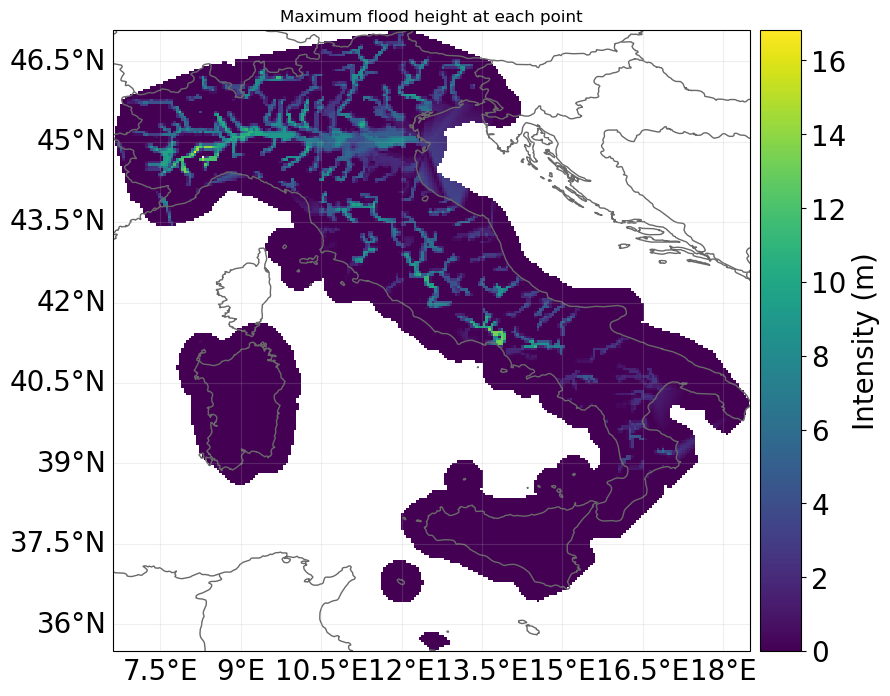

In [2]:
country_name = "Italy"

client = Client()
flood_hazard_set = client.get_hazard(
    "river_flood",
    properties={"country_name": country_name, "climate_scenario": "historical"},
)
ax = flood_hazard_set.plot_intensity(0)
ax.set_title("Maximum flood height at each point");

Plot a single hazard year (just the country-wide footprint of one year of floods):

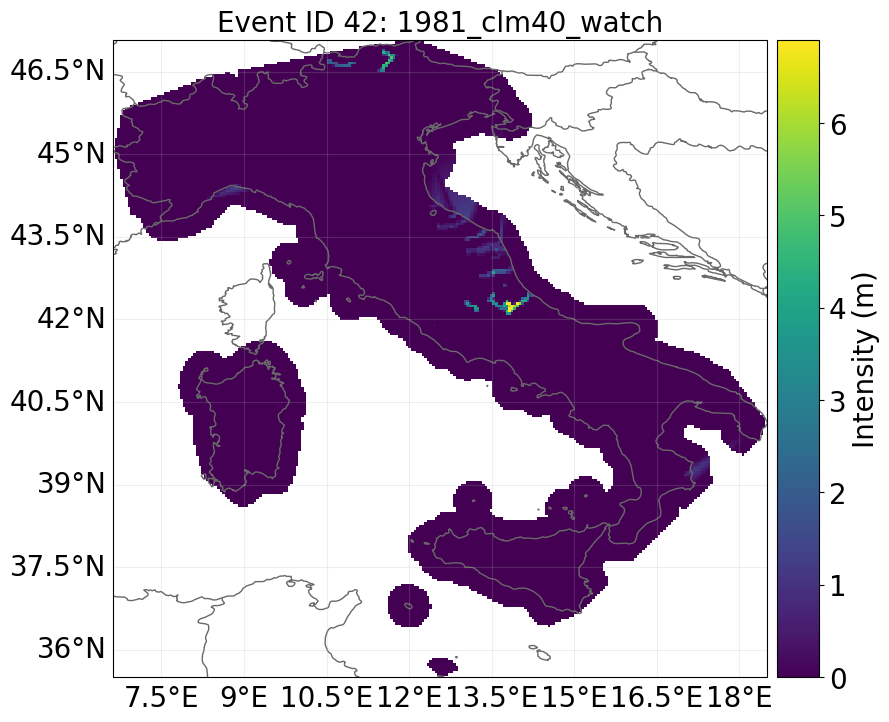

In [3]:
flood_hazard_set.plot_intensity(42);

Get a monetary estimate of assets in the country (e.g., think of a proxy for building values) and plot them:

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


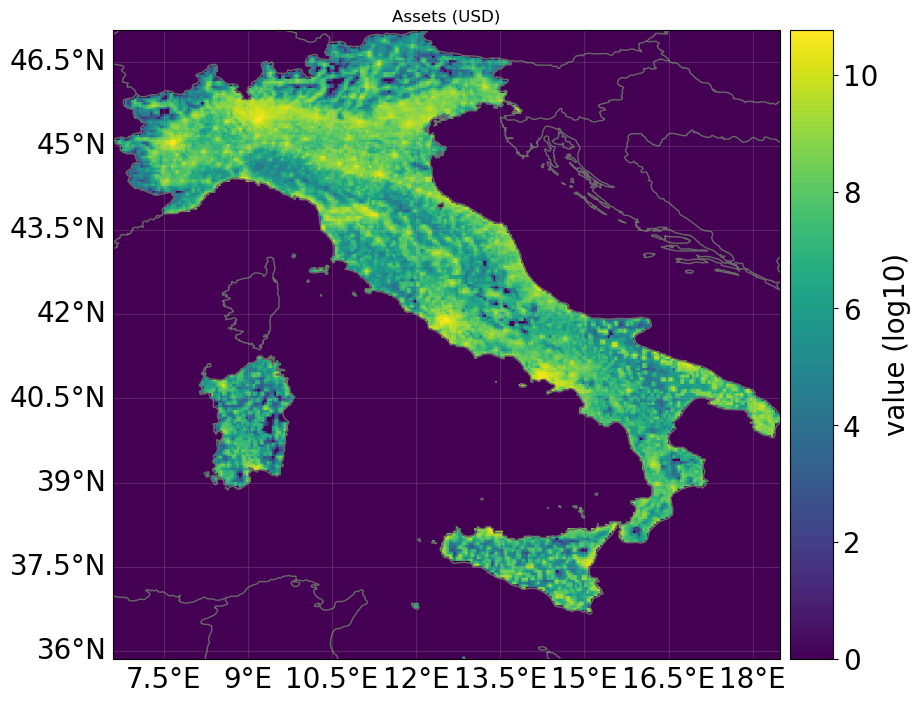

In [4]:
country_assets = client.get_litpop(country=country_name)

ax = country_assets.plot_raster()
ax.set_title(f"Assets ({country_assets.value_unit})");

Define and plot the impact function, the relation between flood hight (horizontal axis) and damage as % of value (vertical axis). MDR is the mean damage ratio, i.e. that’s the curve the asset value gets multiplied with. Ignore MDD and PAA for the time being):

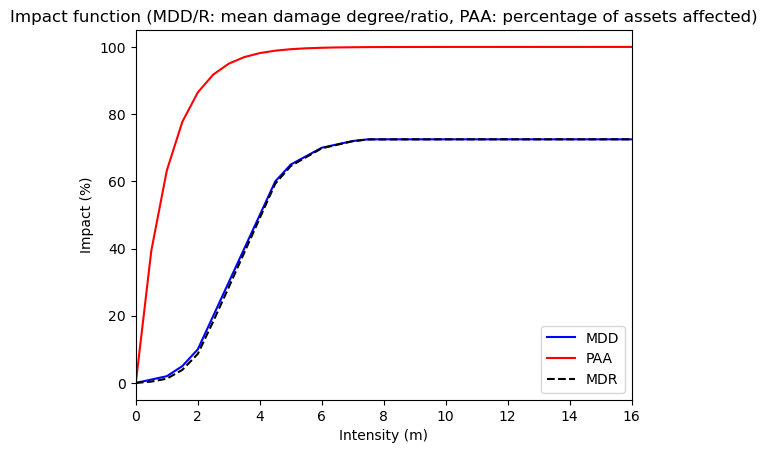

In [5]:
impfset = ImpactFuncSet()
impf = ImpactFunc()
# based on iaimip test runs in MATLAB, ca 2017, with impact function 20160929, a dummy FL damage function, a copy of TS
impf.intensity = np.array(
    [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 10, 16]
)
impf.mdd = np.array(
    [
        0,
        0.01,
        0.02,
        0.05,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.65,
        0.675,
        0.7,
        0.71,
        0.72,
        0.725,
        0.725,
        0.725,
        0.725,
    ]
)
impf.paa = np.array(
    [
        0,
        0.39346934,
        0.632120559,
        0.77686984,
        0.864664717,
        0.917915001,
        0.950212932,
        0.969802617,
        0.981684361,
        0.988891003,
        0.993262053,
        0.995913229,
        0.997521248,
        0.998496561,
        0.999088118,
        0.999446916,
        0.999664537,
        0.9999546,
        0.999999887,
    ]
)
impf.haz_type = "RF"
impf.intensity_unit = "m"
impf.id = 1
impfset.append(impf)
ax = impf.plot()
ax.set_title(
    "Impact function (MDD/R: mean damage degree/ratio, PAA: percentage of assets affected)"
);

Note that impact = asset value multiplied by impact (%) looked up as a function of hazard intensity. Lookup is MDR, which itself is =MDD*PAA. 
Thus the impact calculation is done by a few lines again, looping over all gridpoints and hazard events. One can for example plot the expected annual impact at each gridpoint:

2026-03-18 11:32:19,966 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.083333 degree for 3 coordinates.


/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


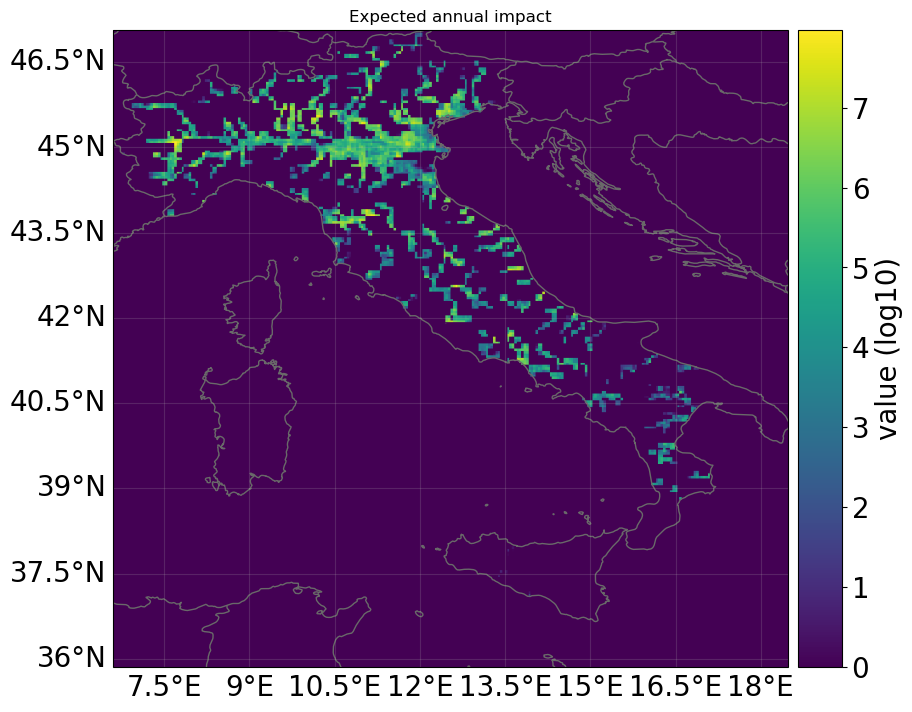

In [6]:
flood_impact = ImpactCalc(country_assets, impfset, flood_hazard_set).impact(
    save_mat=True
)
flood_impact.plot_raster_eai_exposure();

And finally, show the exceedance curve:

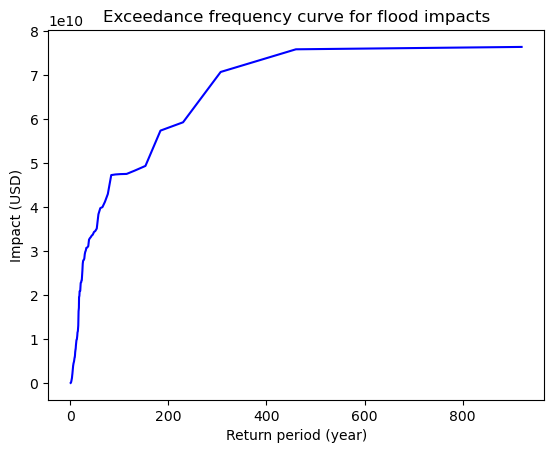

In [7]:
flood_ex_freq = flood_impact.calc_freq_curve()
ax = flood_ex_freq.plot(color="blue", label="flood")
ax.set_title("Exceedance frequency curve for flood impacts");

## Wind impact

Now, also get the wind hazard set, define a wind impact function and run the impact calculation for wind:

In [8]:
wind_hazard_set = client.get_hazard(
    "storm_europe", properties={"country_name": country_name}
)

# we brielfy define a dummy impact function for wind, too:
impf = ImpactFunc()
impf.intensity = np.array(
    [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 100, 160]
)
impf.mdd = np.array(
    [
        0,
        0,
        0,
        0.001,
        0.002,
        0.005,
        0.01,
        0.02,
        0.03,
        0.04,
        0.05,
        0.06,
        0.065,
        0.0675,
        0.07,
        0.071,
        0.072,
        0.0725,
        0.0725,
    ]
)
impf.paa = np.array(
    [
        0,
        0.39346934,
        0.632120559,
        0.77686984,
        0.864664717,
        0.917915001,
        0.950212932,
        0.969802617,
        0.981684361,
        0.988891003,
        0.993262053,
        0.995913229,
        0.997521248,
        0.998496561,
        0.999088118,
        0.999446916,
        0.999664537,
        0.9999546,
        0.999999887,
    ]
)
impf.haz_type = "WS"
impf.intensity_unit = "m/s"
impf.id = 1
impfset.append(impf)

# we run the impact calculation for wind:
wind_impact = ImpactCalc(country_assets, impfset, wind_hazard_set).impact()

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


2026-03-18 11:32:27,430 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.078125 degree for 1 coordinates.


Text(0.5, 1.0, 'Occurrence exceedance frequency curve for wind')

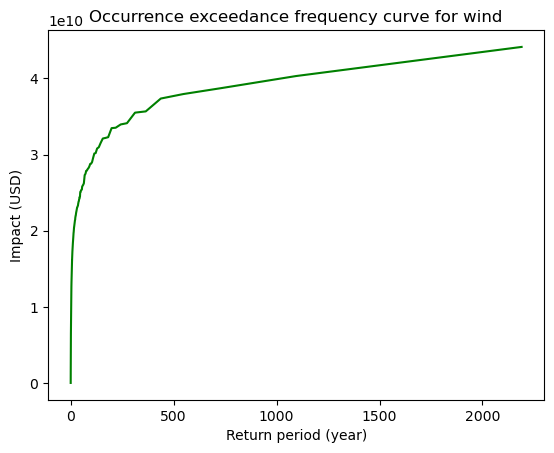

In [9]:
wind_ex_freq = wind_impact.calc_freq_curve()
ax = wind_ex_freq.plot(color="green", label="wind")
ax.set_title("Occurrence exceedance frequency curve for wind")

## Hail impact

Finally, also download the hail hazard set, define a hail impact function and run the impact calculation for hail:

In [10]:
hail_hazard_set = client.get_hazard(
    "hail",
    properties={
        "country_iso3alpha": country_to_iso(country_name),
        "data_source": "model",
        "climate_scenario": "REF",
    },
)

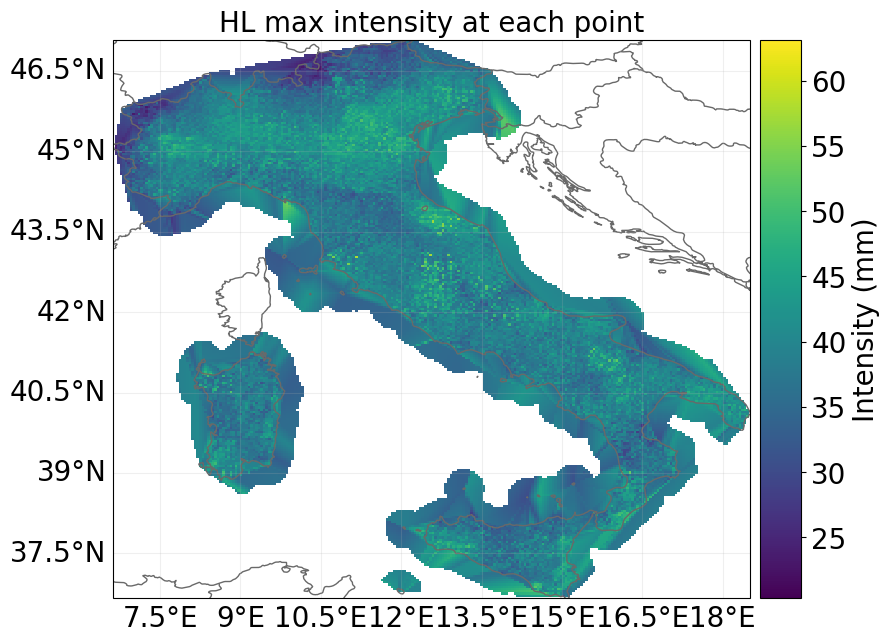

In [11]:
hail_hazard_set.plot_intensity(0);

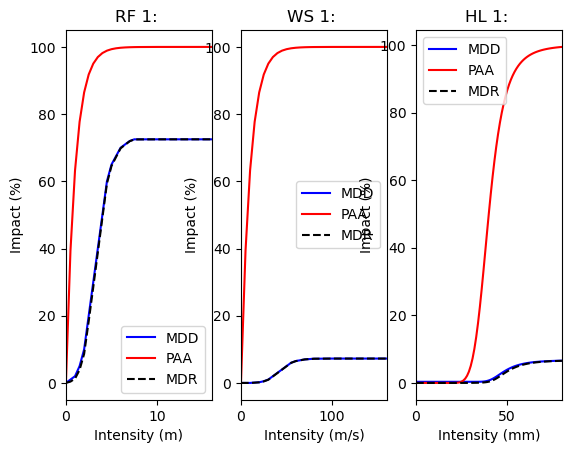

In [12]:
def sigmoid_mod(values, v_half, v_thresh, p, S):
    v_norm = np.maximum(values - v_thresh, 0) / (v_half - v_thresh)
    return S * v_norm**p / (1 + v_norm**p)


def quartic_func(x, a4, a2, a0):
    return a4 * x**4 + a2 * x**2 + a0


# we define an function for hail (similar to https://doi.org/10.1016/j.cliser.2025.100630):
hail_intensities = np.linspace(0, 80, 81)
hail_paa = sigmoid_mod(hail_intensities, 39.9, 17.8, 4.95, 1.0)
hail_mdd = quartic_func(hail_paa, 0.064, 0.0, 0.00333)
impf = ImpactFunc()
impf.intensity = hail_intensities
impf.mdd = hail_mdd
impf.paa = hail_paa
impf.haz_type = "HL"
impf.intensity_unit = "mm"
impf.id = 1
impfset.append(impf)
impfset.plot()

# we run the impact calculation for hail:
country_assets.assign_centroids(hail_hazard_set, threshold=100)
hail_impact = ImpactCalc(country_assets, impfset, hail_hazard_set).impact(
    assign_centroids=False
)

## Computing single hazard yearsets and combining them

The CLIMADA yearsets functionality resamples impact objects to simulate cummulative yearly impact values.

### Yearsets wind

In [13]:
?yearsets.impact_yearset

Signature:
yearsets.impact_yearset(
    imp,
    sampled_years,
    lam=None,
    correction_fac=True,
    with_replacement=False,
    seed=None,
)
Docstring:
Create a yearset of impacts (yimp) containing a probabilistic impact for each year
in the sampled_years list by sampling events from the impact received as input with a
Poisson distribution centered around lam per year (lam = sum(imp.frequency)).
In contrast to the expected annual impact (eai) yimp contains impact values that
differ among years. When correction factor is true, the yimp are scaled such
that the average over all years is equal to the eai.

Parameters
-----------
    imp : climada.engine.Impact()
        impact object containing impacts per event
    sampled_years : list
        A list of years that shall be covered by the resulting yimp.
    lam: float, optional
        The parameter (i.e., the mean) of the Poisson distribution to sample the number of
        events per year. If no lambda value is given, the defaul

Let's start by defining a number of years to sample.

In [14]:
n_sampled_years = 2000

The number of events per year are based on a Poisson distribution.

In [15]:
lam = np.sum(wind_impact.frequency)
events_per_year = yearsets.sample_from_poisson(n_sampled_years, lam)
print(events_per_year[0:5])

[2 2 2 2 2]


We can now compute the wind impact yearsets.

In [16]:
yearset_wind, sampling_vect = yearsets.impact_yearset(
    wind_impact, sampled_years=list(range(1, n_sampled_years + 1)), correction_fac=False
)

CLIMADA yearsets do not inlcude spatial information. Below, we manually add them by constructing the impact matrix of the yearset and corresponding risk metrics.

In [17]:
sparse_matrix = wind_impact.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sparse_matrix[indices, :].sum(axis=0)
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yearset_wind.imp_mat = summed_matrix

yearset_wind.coord_exp = wind_impact.coord_exp
yearset_hail.at_event, yearset_wind.eai_exp, yearset_wind.aai_agg = (
    ImpactCalc.risk_metrics(yearset_wind.imp_mat, yearset_wind.frequency)
)

NameError: name 'yearset_hail' is not defined

Finally, we compute the resulting exceedance curves. Note that the original exceednace curve (labeled as "event-based") differs significantly from the annual one (labeled as "annual"), as the first shows how often impact values are exceeded  in single wind events, while the second shows how often cummulated annual wind impact values are exceeded. 

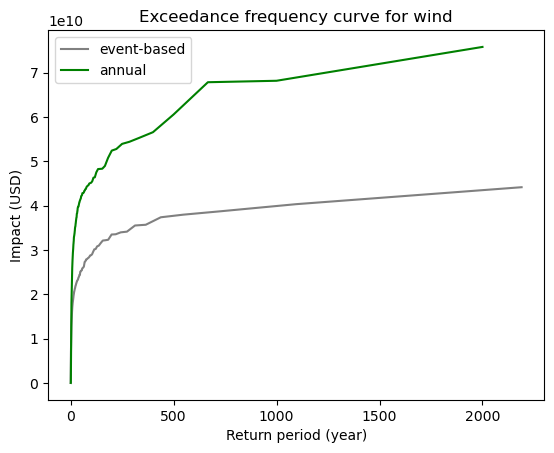

In [ ]:
wind_ex_freq = wind_impact.calc_freq_curve()
ax = wind_ex_freq.plot(color="gray", label="event-based")
wind_ex_freq_yearset = yearset_wind.calc_freq_curve()
wind_ex_freq_yearset.plot(axis=ax, color="green", label="annual")
ax.set_title("Exceedance frequency curve for wind")
ax.legend();

### Yearsets flood

For floods, the events in the hazard object already correspond to years. We can still use the yearsets functionality to sample more years, including combinations of the original events (alias years).

In [ ]:
yearset_flood, sampling_vect = yearsets.impact_yearset(
    flood_impact,
    sampled_years=list(range(1, n_sampled_years + 1)),
    correction_fac=False,
)
sparse_matrix = flood_impact.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sparse_matrix[indices, :].sum(axis=0)
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yearset_flood.imp_mat = summed_matrix
yearset_flood.frequency = np.ones(len(yearset_flood.frequency)) / len(
    yearset_flood.frequency
)
yearset_flood.event_name = yearset_flood.event_id
yearset_flood.coord_exp = flood_impact.coord_exp
yearset_flood.at_event, yearset_flood.eai_exp, yearset_flood.aai_agg = (
    ImpactCalc.risk_metrics(yearset_flood.imp_mat, yearset_flood.frequency)
)

Just to illustrate, as the flood hazard event set is already an annual hazard event set (i.e. it contains the maximum annual flood height, not per occurrence as for wind). Thus "event-based" is annual already and the curves match (modulo sampling error). The one labeled "annual" covers 2000 years due to the resampling.

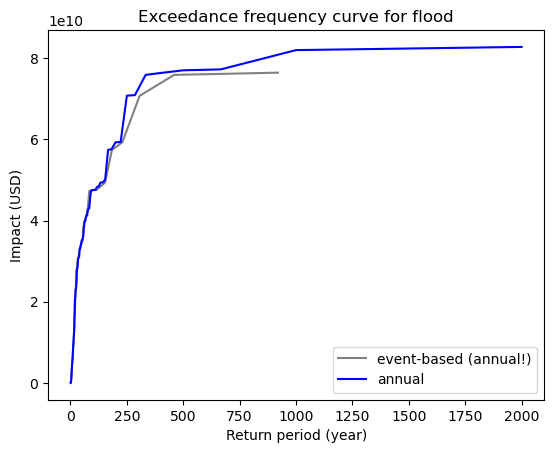

In [ ]:
flood_ex_freq = flood_impact.calc_freq_curve()
ax = flood_ex_freq.plot(color="gray", label="event-based (annual!)")
flood_ex_freq_yearset = yearset_flood.calc_freq_curve()
flood_ex_freq_yearset.plot(axis=ax, color="blue", label="annual")
ax.set_title("Exceedance frequency curve for flood")
ax.legend()

### Yearsets hail

The sampling of hail impact yearsets follows similar to that of winds.

In [ ]:
yearset_hail, sampling_vect = yearsets.impact_yearset(
    hail_impact, sampled_years=list(range(1, n_sampled_years + 1)), correction_fac=False
)

sparse_matrix = hail_impact.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(sparse_matrix[indices, :].sum(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)

yearset_hail.imp_mat = summed_matrix
yearset_hail.event_name = yearset_hail.event_id
yearset_hail.coord_exp = hail_impact.coord_exp

yearset_hail.at_event, yearset_hail.eai_exp, yearset_hail.aai_agg = (
    ImpactCalc.risk_metrics(yearset_hail.imp_mat, yearset_hail.frequency)
)

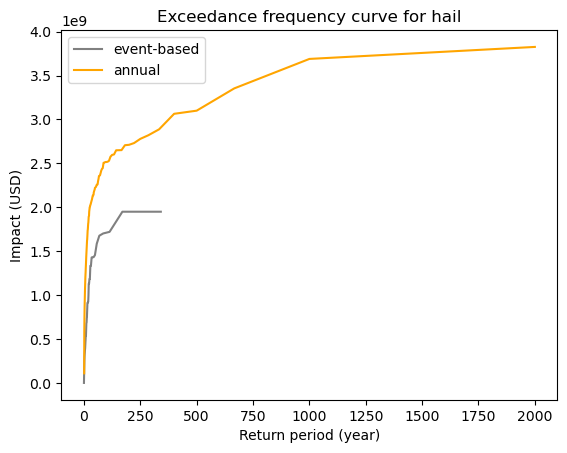

In [ ]:
hail_ex_freq = hail_impact.calc_freq_curve()
ax = hail_ex_freq.plot(color="gray", label="event-based")
hail_ex_freq_yearset = yearset_hail.calc_freq_curve()
hail_ex_freq_yearset.plot(axis=ax, color="orange", label="annual")
ax.set_title("Exceedance frequency curve for hail")
ax.legend();

### Combined yearsets

This is a function that allows to combine the hazards by date or event name, we can also provide the exposures to cap the impacts at exposure value:

In [ ]:
def combine_impacts(impact_list, how="sum", by="date", exp=None):
    """
    Combine multiple Impact objects based on a specified method.

    Parameters
    ----------
    impact_list : list or dict
        List or dictionary of Impact objects with the same coordinates and dates.
    how : str, optional
        Method to combine impacts, options are 'sum', 'max', or 'min'. Default is 'sum'.
    by : str, optional
        Common attribute used to combine events, can be 'date' or 'event_name'. Default is 'date'.
    exp : Exposure, optional
        If provided, impacts are capped at exposure values.

    Returns
    -------
    Impact
        Combined Impact object.
    """
    if isinstance(impact_list, dict):
        impact_list = list(impact_list.values())

    imp0 = copy.deepcopy(impact_list[0])
    for imp in impact_list:
        if imp.unit != imp0.unit:
            raise ValueError(
                "The impacts do not have the same units and cannot be combined."
            )
        if imp.imp_mat.nnz == 0:
            raise ValueError("imp_mat contains only zero values.")
        if np.any(imp.coord_exp != imp0.coord_exp):
            raise ValueError(
                "All impacts must have the same coordinates to be combined."
            )
        if by == "date" and np.any(imp.date != imp0.date):
            raise ValueError(
                "All impacts must have the same dates to be combined by date."
            )
        if by == "event_name" and np.any(imp.event_name != imp0.event_name):
            raise ValueError(
                "All impacts must have the same event_name to be combined by event_name."
            )

    if by in ["event_name", "date"]:
        aggr_attr = {"event_name": imp0.event_name, "date": imp0.date}
        unique_elements = np.unique(aggr_attr[by])
        element_to_int = {element: i + 1 for i, element in enumerate(unique_elements)}
        imp0.event_id = np.array([element_to_int[element] for element in aggr_attr[by]])
    else:
        raise NotImplementedError(
            "This method only supports combining by 'date' or 'event_name'."
        )

    if how == "sum":
        imp_mat = sum(imp.imp_mat for imp in impact_list)
    elif how == "min":
        imp_mat = impact_list[0].imp_mat
        for imp in impact_list[1:]:
            imp_mat = imp_mat.minimum(imp.imp_mat)
    elif how == "max":
        imp_mat = impact_list[0].imp_mat
        for imp in impact_list[1:]:
            imp_mat = imp_mat.maximum(imp.imp_mat)
    else:
        raise ValueError(
            f"'{how}' is not a valid method. The implemented methods are 'sum', 'max', or 'min'."
        )

    if exp is not None:
        m1 = imp_mat.data
        m2 = exp.gdf.value[imp_mat.nonzero()[1]]
        imp_mat = sp.csr_matrix((np.minimum(m1, m2), imp_mat.indices, imp_mat.indptr))
        imp_mat.eliminate_zeros()

    years = np.unique([date.fromordinal(int(d)).year for d in imp0.date])
    frequency = np.ones(imp_mat.shape[0]) / len(np.unique(years))
    at_event, eai_exp, aai_agg = ImpactCalc.risk_metrics(imp_mat, frequency)

    event_id, event_name = (
        (imp0.event_id, imp0.event_name)
        if all(
            np.array_equal(imp.event_id, imp0.event_id)
            and np.array_equal(imp.event_name, imp0.event_name)
            for imp in impact_list
        )
        else (np.arange(1, len(at_event) + 1), np.arange(1, len(at_event) + 1))
    )

    return Impact(
        event_id=event_id,
        event_name=event_name,
        date=imp0.date,
        at_event=at_event,
        eai_exp=eai_exp,
        aai_agg=aai_agg,
        coord_exp=imp0.coord_exp,
        crs=DEF_CRS,
        imp_mat=imp_mat,
        frequency=frequency,
        unit=imp0.unit,
    )

In [ ]:
combined_impact = combine_impacts([yearset_wind, yearset_flood, yearset_hail])

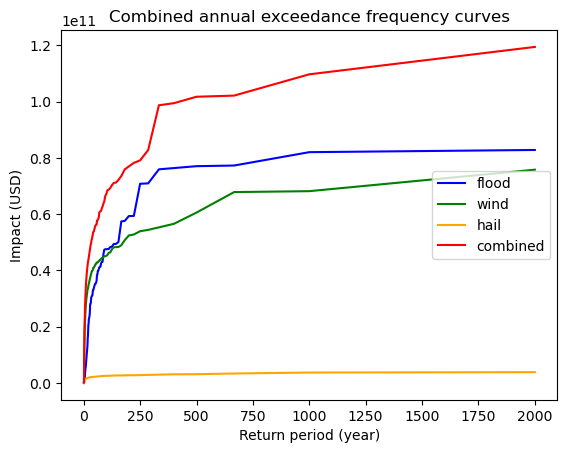

In [ ]:
flood_ex_freq = yearset_flood.calc_freq_curve()
ax = flood_ex_freq.plot(color="blue", label="flood")
wind_ex_freq = yearset_wind.calc_freq_curve()
wind_ex_freq.plot(axis=ax, color="green", label="wind")
hail_ex_freq = yearset_hail.calc_freq_curve()
hail_ex_freq.plot(axis=ax, color="orange", label="hail")
combined_freq = combined_impact.calc_freq_curve()
combined_freq.plot(axis=ax, color="red", label="combined")
ax.set_title("Combined annual exceedance frequency curves")
ax.legend();